<a href="https://colab.research.google.com/github/kuxx12257/LOWESS_w.s.cleveland_research_reproduction/blob/main/lowess_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIM: to implement the lowess model from scratch and compare it with the model impelmentation using pyton data science libraries

In [8]:
import numpy as np

def lowess(x, y, f=0.3):
    n = len(x)
    y_pred = np.zeros(n)

    for i in range(n):

        distances = np.abs(x - x[i])


        h = np.sort(distances)[int(f * n)]


        w = (1 - (distances / h)**3)**3
        w[distances > h] = 0


        W = np.diag(w)
        X = np.vstack([np.ones(n), x]).T

        beta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)


        y_pred[i] = beta[0] + beta[1] * x[i]

    return y_pred

In [9]:
np.random.seed(0)

x=np.linspace(0,10,100) #equally spaced data points
y=np.e**(np.sin(x)+np.cos(x))+np.random.normal(0,0.3,100)

In [10]:
lowess(x,y,f=0.3)

array([4.31830799, 4.23821508, 4.15403119, 4.06586469, 3.97398444,
       3.87871119, 3.78039322, 3.67945856, 3.57634828, 3.47150787,
       3.3653697 , 3.25830101, 3.15046593, 3.04112715, 2.92591799,
       2.79079634, 2.61575844, 2.43608154, 2.25425584, 2.07133507,
       1.88820289, 1.7072607 , 1.53168715, 1.36540731, 1.21195787,
       1.07337867, 0.95012323, 0.84127901, 0.74536771, 0.66103681,
       0.58760703, 0.52366939, 0.4671926 , 0.41658723, 0.37138821,
       0.33190945, 0.29905649, 0.27279634, 0.25316617, 0.24018283,
       0.23339897, 0.23373391, 0.24230387, 0.25983402, 0.28629919,
       0.32111974, 0.36423546, 0.41618151, 0.47849312, 0.55268872,
       0.63929947, 0.73851741, 0.84984077, 0.97236193, 1.10606939,
       1.25100499, 1.40738898, 1.57514399, 1.75283095, 1.93718469,
       2.12424444, 2.30999183, 2.48997188, 2.65927819, 2.81394463,
       2.9506129 , 3.06646715, 3.1589424 , 3.2270868 , 3.27048308,
       3.28817376, 3.28011446, 3.24719509, 3.19041442, 3.11043

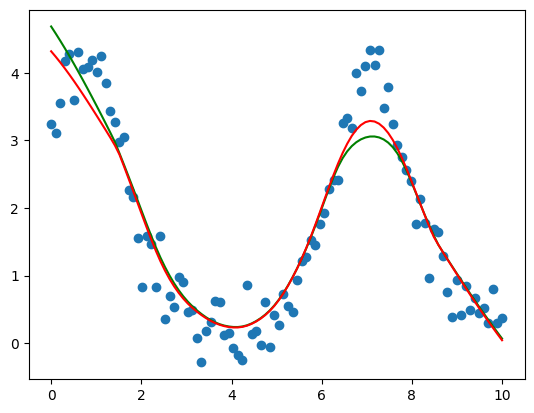

In [11]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
plt.scatter(x,y,label="data")
reg=sm.nonparametric.lowess(y,x,frac=0.3)
plt.plot(reg[:,0],reg[:,1],color="green")
plt.plot(x, lowess(x,y,f=0.3), label="LOWESS fit", color="red")
plt.title("lowess_scratch v/s lowess_library")
plt.show()
#IN THE PLOT we can see the plot of the lowess model implemented from scratch and the lowess model implemented using the pyton library
#as we can observe there is not much difference between the fits
# hence we dont need to implement the model from scratch evrytime and could
# simply use the python data science libraries